# The Concentration of Success: Analysing Spotify’s Top 1,000 Most Streamed Global Hits (2014–2026)

**Student Number:** 740095006

## 1. Introduction

The modern music streaming industry is characterised by extreme concentration of success. A small number of artists and individual tracks account for a disproportionately large share of global streams, while the vast majority of songs receive relatively little attention.

This project analyses the top 1,000 most streamed songs on Spotify’s Global chart from 2014 to 2026. Using publicly available data from Kworb.net, it examines patterns of streaming success, chart performance, and artist dominance.

Through web scraping, data cleaning, visualisation, and regression analysis, this study highlights the “winner-takes-most” dynamics that define today’s digital music market.

In [355]:
import pandas as pd
from IPython.display import Image

# Load cleaned data
df = pd.read_csv("data/processed/spotify_cleaned.csv")
print(f"Dataset contains {len(df)} tracks")
df.head()

Dataset contains 1000 tracks


,track_name,total_streams_while_in_Top_200 (millions),T10,Pk,(x?),PkStreams,Total,artist,title
0,Ed Sheeran - Perfect,445,15.0,4,NaN,24763619,3623472607,Ed Sheeran,Perfect
1,Imagine Dragons - Believer,425,NaN,16,NaN,16864827,3353483545,Imagine Dragons,Believer
2,Ed Sheeran - Shape of You,412,34.0,1,(x14),64217796,4338426724,Ed Sheeran,Shape of You
3,OneRepublic - Counting Stars,412,24.0,3,(x5),11170130,2617021035,OneRepublic,Counting Stars
4,Vance Joy - Riptide,403,NaN,16,NaN,16836644,2813812435,Vance Joy,Riptide


## 2. Data Overview

In [356]:
print("Top 10 Most Streamed Tracks")
df[['artist', 'title', 'total_streams_while_in_Top_200 (millions)']].head(10)

Top 10 Most Streamed Tracks


,artist,title,total_streams_while_in_Top_200 (millions)
0,Ed Sheeran,Perfect,445
1,Imagine Dragons,Believer,425
2,Ed Sheeran,Shape of You,412
3,OneRepublic,Counting Stars,412
4,Vance Joy,Riptide,403
5,Billie Eilish,lovely,400
6,James Arthur,Say You Won't Let Go,352
7,Lewis Capaldi,Someone You Loved,343
8,The Weeknd,Blinding Lights,335
9,Post Malone,Sunflower - Spider-Man: Into the Spider-Verse,335


### Data Dictionary

The table below explains the meaning of each column in the dataset:

| Column Name | Description |
|-|-|
| `track_name`| Original combined "Artist - Title" as shown on the Spotify chart |
| `total_streams_while_in_Top_200 (millions)` | Cumulative total streams (in millions) while the song was ranked in Spotify’s Global Top 200 weekly chart |
| `T10`| Number of weeks the song spent in the **Top 10** of the Global Weekly Chart |
| `Pk`| The peak chart position the song ever reached |
| `(x?)`| How many times the song reached its peak position |
| `PkStreams`| Number of streams the song had when it first reached its peak position |
| `Total`| Alternative total streams metric provided by Kworb |
| `artist`| Artist name (extracted from `track_name`) |
| `title`| Song title (extracted from `track_name`) |

**Note:** The streaming figures represent cumulative streams only while the song was actively charting in the Global Top 200. True lifetime streams on Spotify are substantially higher.

## 3. Visual Analysis

**Figure 1: Top 10 Artists by Total Streams**

This bar chart displays the ten artists with the highest cumulative streams while their songs were ranked in Spotify’s Global Top 200 weekly chart. Ed Sheeran and The Weeknd lead by a substantial margin, each accumulating well over 2 billion streams in the dataset. 

The visualisation clearly illustrates one of the most striking features of the modern music streaming industry: **extreme concentration of success**. The difference between the top two artists and the rest of the top 10 is very large, and the gap continues to widen as we move down the ranking. This pattern suggests that artist popularity, brand strength, and consistent hit-making ability create a significant competitive advantage in the digital music market.

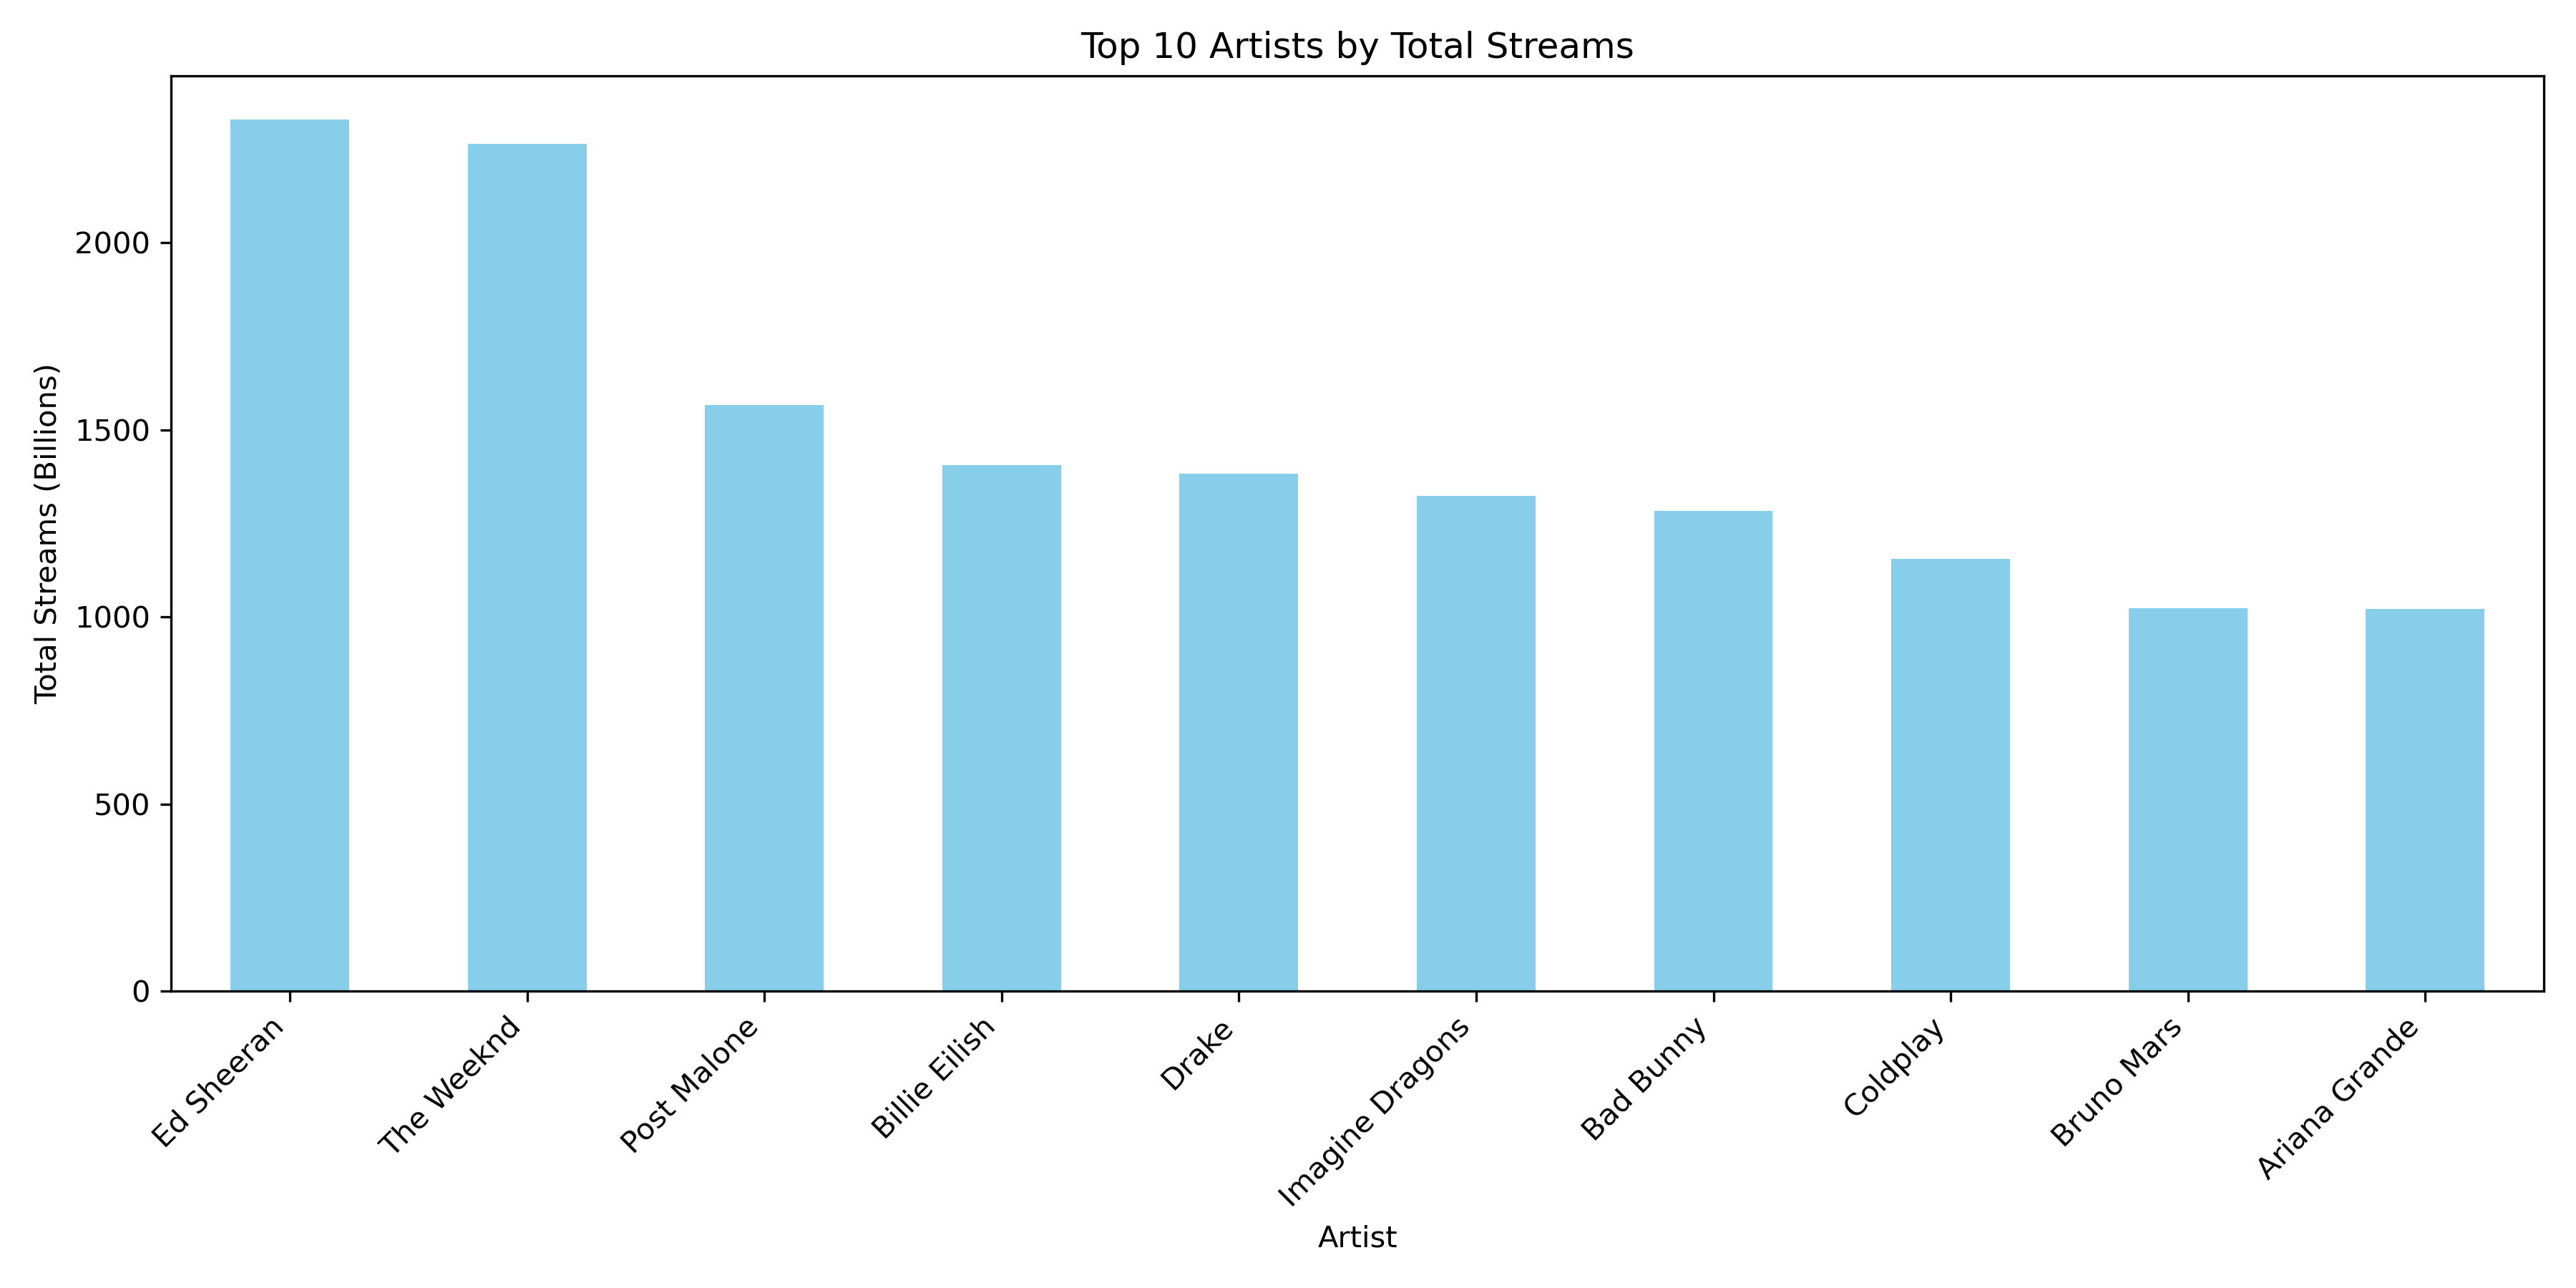

In [357]:
Image("output/plots/top_10_artists.png")

**Figure 2: Distribution of Total Streams Across Top 1,000 Songs (Log Scale)**

This histogram shows how total streams are distributed among the top 1,000 most streamed songs in the dataset. Even when presented on a logarithmic scale, the distribution remains strongly right-skewed. 

The majority of songs fall in the lower range (roughly 10–100 million streams), while only a small minority of tracks achieve exceptionally high streaming totals (300 million or more). This heavy right skew is a classic “power-law” or “winner-takes-most” distribution, commonly observed in cultural and digital markets. It means that while thousands of songs manage to enter the Global chart, only a tiny fraction become true global blockbusters that drive the majority of streaming activity on the platform.

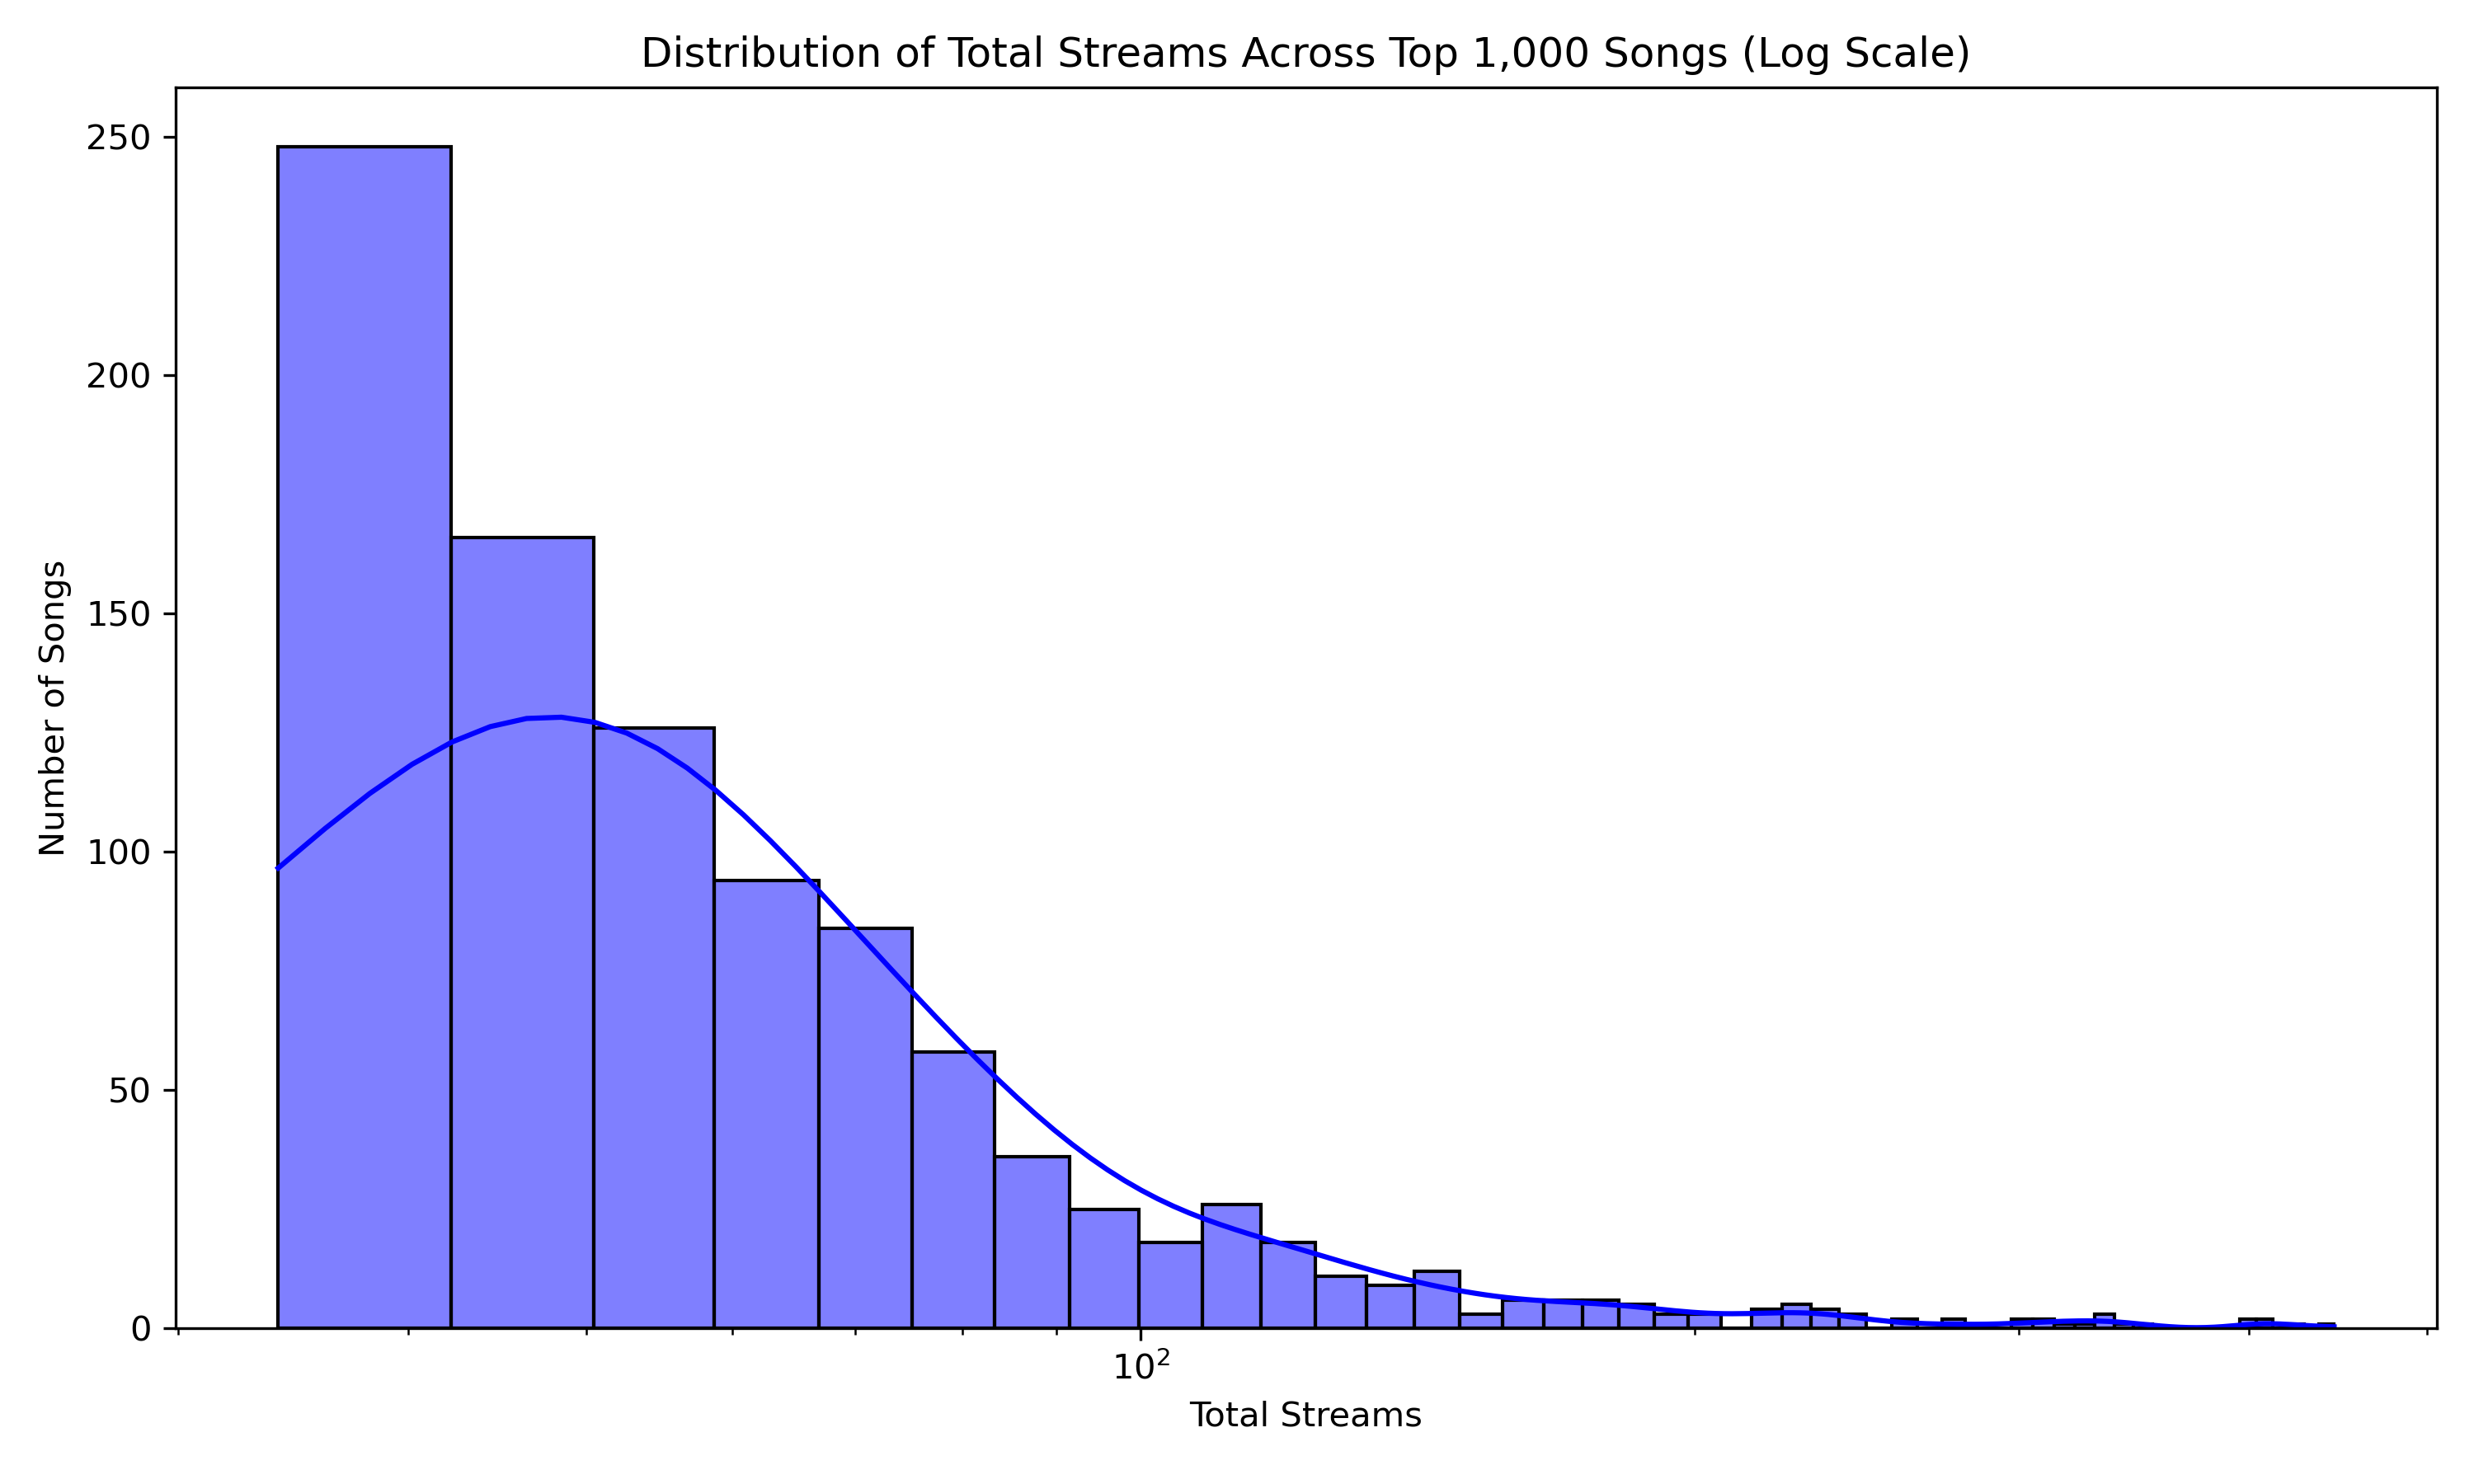

In [358]:
Image("output/plots/streams_distribution.png")

**Figure 3: Top 10 Individual Songs by Total Streams**

This horizontal bar chart ranks the ten individual songs with the highest total streams in the dataset. “Perfect” by Ed Sheeran leads the ranking, followed by “Believer” by Imagine Dragons. Several artists appear more than once in the top 10 (e.g., Ed Sheeran and OneRepublic), indicating that certain artists are particularly successful at producing multiple high-performing tracks.

The chart reinforces two important insights. First, streaming success is extremely concentrated at the song level — a very small number of individual tracks dominate global listening. Second, the most successful songs often come from artists who already have strong brand recognition and consistent chart presence. This combination of artist power and individual song quality appears to be a key driver of exceptional streaming performance.

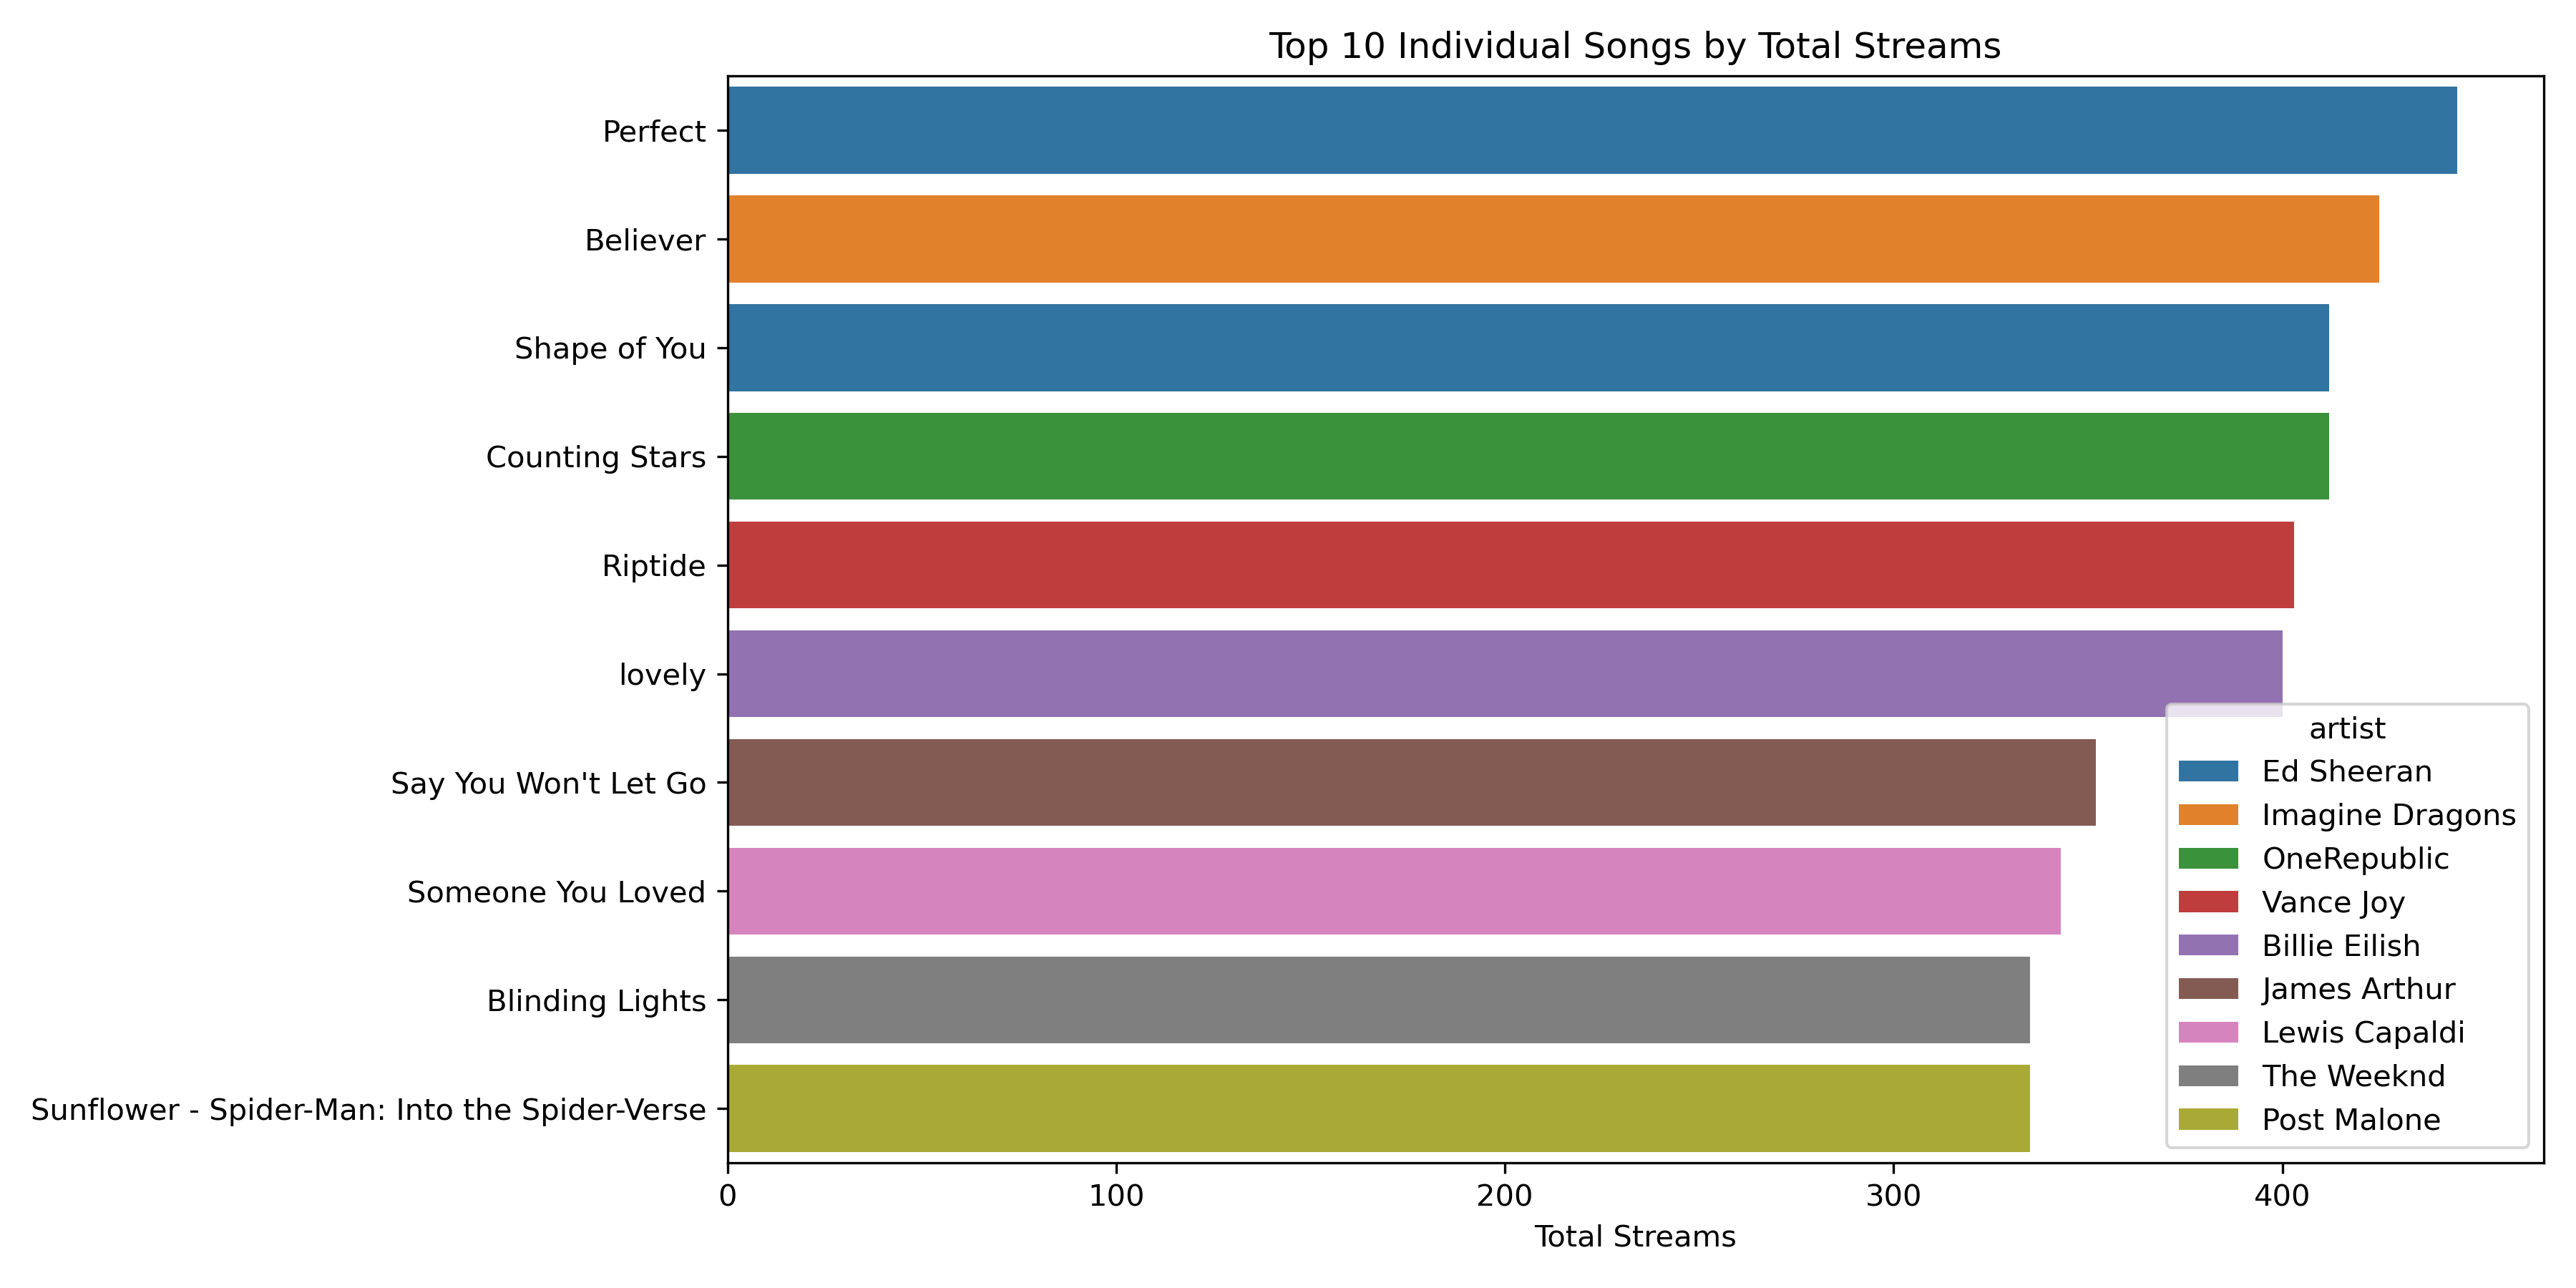

In [359]:
Image("output/plots/top_10_songs.png")

## 4. Regression Analysis

A simple Ordinary Least Squares (OLS) regression was performed to examine the relationship between chart performance and total streams.

In [360]:
import statsmodels.api as sm

# Remove rows with missing values
df_reg = df.dropna(subset=['Pk', 'T10', 'total_streams_while_in_Top_200 (millions)'])

X = sm.add_constant(df_reg[['Pk', 'T10']])
y = df_reg['total_streams_while_in_Top_200 (millions)']

model = sm.OLS(y, X).fit()
print(model.summary())

                                        OLS Regression Results                                       
Dep. Variable:     total_streams_while_in_Top_200 (millions)   R-squared:                       0.164
Model:                                                   OLS   Adj. R-squared:                  0.161
Method:                                        Least Squares   F-statistic:                     46.95
Date:                                       Fri, 08 May 2026   Prob (F-statistic):           2.43e-19
Time:                                               04:21:17   Log-Likelihood:                -2582.5
No. Observations:                                        480   AIC:                             5171.
Df Residuals:                                            477   BIC:                             5184.
Df Model:                                                  2                                         
Covariance Type:                                   nonrobust                      

### Regression Interpretation

- **Peak Position (`Pk`)** has a statistically significant negative coefficient. Songs that reached a higher chart position (lower `Pk` value) tend to accumulate significantly more streams.
- **Weeks in Top 10 (`T10`)** has a positive and significant coefficient. Songs that stay longer in the Top 10 also tend to have higher total streams.

The model demonstrates that chart performance is meaningfully associated with streaming success, although the overall R-squared is modest, indicating that many other factors also influence a song’s popularity.

## 5. Conclusion

This project has demonstrated the highly concentrated nature of success in the global music streaming industry. Analysis of the top 1,000 most streamed songs on Spotify’s Global chart from 2014 to 2026 shows that a small number of superstar artists and blockbuster tracks dominate the majority of streams.

Key findings include a heavily right-skewed distribution of streams and the strong predictive power of chart performance metrics (peak position and weeks in the Top 10).

Through web scraping, systematic data cleaning, effective visualisation, and regression modelling, this study illustrates both the technical workflow of a data science project and important structural characteristics of the modern music market.

**Limitations:**  
The streaming figures represent cumulative totals only while songs were ranked in Spotify’s Global Top 200 weekly chart. True lifetime streams are substantially higher.

**Future Work:**  
Future research could incorporate Spotify audio features (valence, danceability, energy), genre information, or temporal trends to provide an even richer understanding of streaming success.

Overall, this project highlights the “winner-takes-most” dynamics that characterise today’s digital music consumption.

## References
- Spotify Chart Data: [kworb.net](https://kworb.net)
- Python libraries: pandas, matplotlib, seaborn, statsmodels